In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

## Lab 2: Image Stitching with Homographies

In this lab, we will explore image stitching and panorama creation. You will use a homography to register two images together, and implement bilinear interpolation to help accomplish this. As part of the lab, you will also explore image enhancement strategies to improve the quality of image stitching at the seam (the join between two images) relying on your knowledge of image brightness and human perception of this. Collectively, tasks 1-5 will provide a final stitched image. In task 6, you will apply the same code written in tasks 1-5 to create a panorama image using your own photos.

* Task 1: Draw test points on the left image
* Task 2: Use a homography to find the location of these points in the right image
* Task 3: Bilinear interpolation of the right image pixels
* Task 4: Image stitching 
* Task 5: Better blending
* Task 6: Now try your own!

### Academic integrity

Every lab submission will be screened for any collusion and/or plagiarism. Breaches of academic integrity will be investigated thoroughly and may result in a zero for the assessment along with interviews with the plagiarism officers at Monash University.

### Late submissions

The default late submission university penalty will apply.

### Lab Instructions and the Use of Generative AI

You may not use any built-in opencv functions for this lab, other than those used for loading/ saving an image, extracting and matching keypoints, and
computing homographies.
* You may use NumPy for array handling, and vectorizing your code (reducing
the number of for-loops) is encouraged.
* You should use Matplotlib to display images and any intermediate results.
* You may use generative AI.

### Grading
Each lab is worth 8%, and there are a number of sections and tasks with their own weighting. A task is only considered complete if you can demonstrate a working program and show an understanding of the underlying concepts. Note that later tasks should reuse code from earlier tasks.

Masks will be provided based on the correctness of the code, the quality of your results, comments indicating you understand your work, and a discussion of tasks provided at the end of the notebook. 

# Task 1: Draw test points on the left image

Draw the following points on the left image as red crosses. Display the resulting image.

{446 , 499, 1}, {383, 590, 1}, {296 , 499, 1}, {282, 511, 1}, {401 , 508, 1}

Recall from lectures that these 3-element homogeneous coordinates can be transformed to 2D image pixel coordinates by dividing the first and second elements by the third (needed for later tasks).

In [5]:
# Write your code here
import cv2
import numpy as np
import matplotlib.pyplot as plt

left = cv2.imread('left.jpg', cv2.IMREAD_GRAYSCALE)

# Homogeneous points (x, y, w)
points_h = np.array([
    [446, 499, 1],
    [383, 590, 1],
    [296, 499, 1],
    [282, 511, 1],
    [401, 508, 1]
])

# Convert from 3D vector to 2D: x=col, y=row (Where 3D = [x,y,w], and 2D = [x/w, y/w])
left_display = cv2.cvtColor(left, cv2.COLOR_GRAY2RGB)
for i in points_h:
    x, y = int(i[0] / i[2]), int(i[1] / i[2])
    # Draw a cross manually (no cv2.drawMarker)
    size = 10
    left_display[y-size:y+size, x, 0] = 255   # vertical line, red channel
    left_display[y, x-size:x+size, 0] = 255   # horizontal line




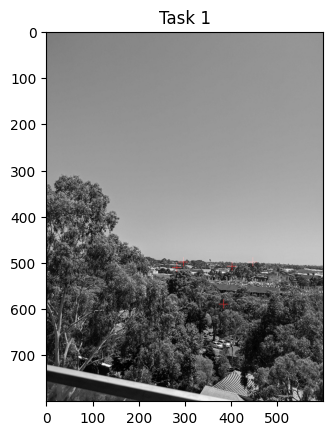

In [6]:
# Show results here
plt.imshow(left_display); plt.title('Task 1'); plt.show()

# Task 2: Use Homography to find right image points


The following homography transforms pixel coordinates between the left and right images as
$$ x_R = H x_L $$

\begin{bmatrix}
1.6011 & 0.0277 & -393.5701 \\
0.3242 & 1.5119 & -228.8918 \\
0.0009 & 0.0002 & 1.0000
\end{bmatrix}

Apply the homography to transform the left image points in Task 1 to their corresponding locations in the right image. Draw the transformed points as red crosses on the right image. Check your result before moving on.


In [7]:
# Write your code here
right = cv2.imread('right.jpg', cv2.IMREAD_GRAYSCALE)

H = np.array([
    [1.6011, 0.0277, -393.5701],
    [0.3242, 1.5119, -228.8918],
    [0.0009, 0.0002,    1.0000]
])

In [8]:
# Print results here
right_pts = []

for pt in points_h:
    x_r = H @ pt             # 3-vector
    x_r = x_r / x_r[2]      # normalise to w=1
    right_pts.append(x_r)
    print(f"Left {pt[:2]} -> Right ({x_r[0]:.2f}, {x_r[1]:.2f})")

Left [446 499] -> Right (222.72, 446.40)
Left [383 590] -> Right (161.34, 538.25)
Left [296 499] -> Right (68.93, 454.92)
Left [282 511] -> Right (53.17, 468.37)
Left [401 508] -> Right (179.52, 457.54)


# Task 3: Bilinear interpolation of the right image

The transformed coordinates can be in between pixel locations. Write a bilinear interpolation function to compute the intensity of the transformed pixel coordinate in right.jpg using intensity values from neighbouring pixel locations. Print the interpolated intensity value for each transformed point in Task 2. The first point should be around 176 whereas the last point should be around 73.

HINT: The bilinear interpolation function should take the transformed pixel coordinate and the intensity values of its four neighbours as input arguments, and should output the interpolated intensity value.

In [10]:
# Write your code here
def bilinear_interpolation(image, x, y):
    """
    image: 2D numpy array (H x W)
    x: float column coordinate
    y: float row coordinate
    returns: interpolated intensity (float)
    """
    x0, y0 = int(np.floor(x)), int(np.floor(y))
    x1, y1 = x0 + 1, y0 + 1
    dx, dy = x - x0, y - y0

    # Clamp to image bounds
    H, W = image.shape
    if x0 < 0 or y0 < 0 or x1 >= W or y1 >= H:
        return 0.0

    # Four neighbours
    I00 = image[y0, x0]
    I10 = image[y0, x1]
    I01 = image[y1, x0]
    I11 = image[y1, x1]

    # Weighted blend
    value = (I00 * (1-dx) * (1-dy) +
             I10 *    dx  * (1-dy) +
             I01 * (1-dx) *    dy  +
             I11 *    dx  *    dy)
    return value

In [14]:
# Show results here
for i, pt in enumerate(points_h):
    x_r, y_r = right_pts[i][0], right_pts[i][1]
    intensity = bilinear_interpolation(right, x_r, y_r)
    print(f"Right point ({x_r:.2f}, {y_r:.2f}) has intensity {intensity:.2f}")

Right point (222.72, 446.40) has intensity 176.00
Right point (161.34, 538.25) has intensity 38.47
Right point (68.93, 454.92) has intensity 69.83
Right point (53.17, 468.37) has intensity 58.19
Right point (179.52, 457.54) has intensity 74.51


# Task 4: Image stitching

Create a 1200x800 (width x height) image and fill the left hand side of this image with the left image. This stitched image will use the left image coordinate system (xl) throughout the stitching process. Next, fill in the remaining pixels on the RHS by transforming their pixel coordinates (left image coordinates) to the right image coordinates via the homography from Task 2 and determining the intensity using your bilinear interpolation implementation. If the right pixel  coordinate is valid, generate the pixel value using bilinear interpolation, but if the right pixel coordinate is invalid, use a pixel value of zero. Display the stitching results. It should look like a wide-angle image with a visible seam where the two images join.

In [16]:
# Write your code here
canvas_w, canvas_h = 1200, 800
left_h, left_w = left.shape   # e.g., 800x600

stitched = np.zeros((canvas_h, canvas_w), dtype=np.float32)

# 1. Fill left portion with left image
stitched[:left_h, :left_w] = left.astype(np.float32)

# 2. For pixels to the RIGHT of the left image edge, fill from right image
for row in range(canvas_h):
    for col in range(left_w, canvas_w):   # start from seam
        # This pixel is in left-image coordinate space
        pt_l = np.array([col, row, 1.0])
        pt_r = H @ pt_l
        pt_r = pt_r / pt_r[2]
        xr, yr = pt_r[0], pt_r[1]

        val = bilinear_interpolation(right, xr, yr)
        stitched[row, col] = val



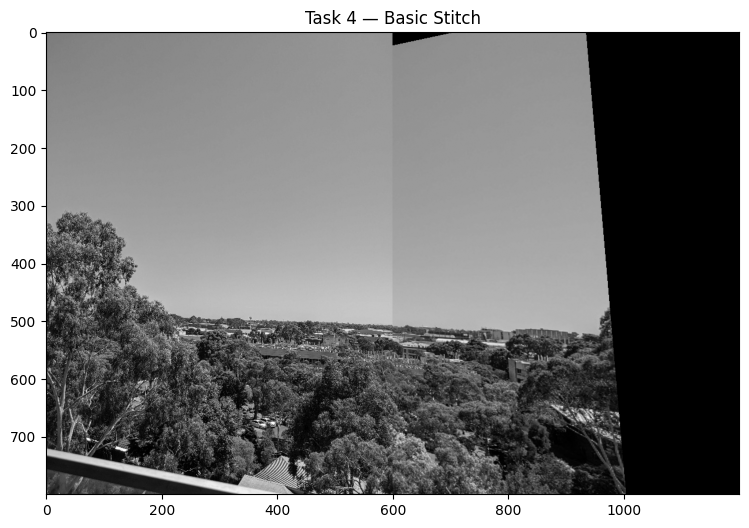

In [17]:
# Show results here

plt.figure(figsize=(14,6))
plt.imshow(stitched, cmap='gray'); plt.title('Task 4 — Basic Stitch')
plt.show()


# Task 5: Better blending

Improve the visual quality of the stitched image by trying the following image processing techniques:

1. Adjust the width of the output image automatically so that fewer black pixels are
visible 
2. Adjust the brightness (by a scaling factor) of each image so that the seam is less
visible
3. Apply a small amount of Gaussian blur or alpha blending near the seam to make
it less visible
4. Adjust the horizontal location of the seam (it can be moved further to the left as
the right image overlaps into the left by quite a few pixels)

Note that you do not have to try all of the above. However, you will only receive a mark here depending on
• the quality of the stitched image
• whether a serious programming attempt is made to improve the visual quality of the stitched image

In [118]:
# ── Task 5: Better Blending ──────────────────────────────────────────────────

right_h, right_w = right.shape

# ── Step 1: Vectorised warp of the right image over the FULL canvas ──────────
# We warp every canvas pixel (not just right of left_w) so we can detect
# where the right image is valid further to the left — needed for seam + blend.
col_idx = np.arange(canvas_w, dtype=np.float64)
row_idx = np.arange(canvas_h, dtype=np.float64)
col_grid, row_grid = np.meshgrid(col_idx, row_idx)
ones = np.ones((canvas_h, canvas_w), dtype=np.float64)

pts_l = np.stack([col_grid, row_grid, ones], axis=0).reshape(3, -1)
pts_r = H @ pts_l
pts_r /= pts_r[2]   # normalise homogeneous coords

xr = pts_r[0].reshape(canvas_h, canvas_w)
yr = pts_r[1].reshape(canvas_h, canvas_w)

# Boolean mask: canvas pixels that map to valid right-image coords
valid = (xr >= 0) & (xr < right_w - 1) & (yr >= 0) & (yr < right_h - 1)

# Vectorised bilinear sampling of the right image
x0 = np.clip(np.floor(xr).astype(int), 0, right_w - 2)
y0 = np.clip(np.floor(yr).astype(int), 0, right_h - 2)
dx = xr - np.floor(xr)
dy = yr - np.floor(yr)

right_warped = (right[y0,   x0  ] * (1-dx) * (1-dy) +
                right[y0,   x0+1] *    dx  * (1-dy) +
                right[y0+1, x0  ] * (1-dx) *    dy  +
                right[y0+1, x0+1] *    dx  *    dy).astype(np.float32)
right_warped[~valid] = 0.0

# ── Step 2: Left image padded to full canvas ──────────────────────────────────
left_canvas = np.zeros((canvas_h, canvas_w), dtype=np.float32)
left_canvas[:left_h, :left_w] = left.astype(np.float32)

# ── Step 3: Move the seam left ────────────────────────────────────────────────
# The right image overlaps significantly into the left-image region.
# Find the leftmost column where >50% of rows have valid right-image data.
col_coverage = valid.sum(axis=0) / canvas_h
seam_x = int(np.argmax(col_coverage > 0.5))
print(f"Seam moved from col {left_w} -> col {seam_x}")

# ── Step 4: Brightness matching ───────────────────────────────────────────────
# Scale the right image so its mean intensity matches the left image in the
# overlap zone. The HVS is highly sensitive to brightness step-changes, so
# matching means significantly reduces the perceptual salience of the seam.
overlap_mask = valid[:, seam_x:left_w]
left_vals  =  left_canvas[:, seam_x:left_w][overlap_mask]
right_vals = right_warped[:, seam_x:left_w][overlap_mask]
brightness_scale = (left_vals.mean() / right_vals.mean()) if right_vals.mean() > 0 else 1.0
right_warped_sc = np.clip(right_warped * brightness_scale, 0, 255).astype(np.float32)
print(f"Brightness scale applied to right image: {brightness_scale:.4f}")

# ── Step 5: Alpha blend across a transition zone around the seam ──────────────
# alpha=0 -> pure left image; alpha=1 -> pure right image.
# A gradual crossfade is much less visible than a hard cut because the HVS
# detects abrupt intensity steps far more readily than smooth ramps.
blend_w = 200   # crossfade width in pixels

alpha_cols = np.zeros(canvas_w, dtype=np.float32)
alpha_cols[seam_x : seam_x + blend_w] = np.linspace(0, 1, blend_w)
alpha_cols[seam_x + blend_w :]        = 1.0
alpha_map = np.broadcast_to(alpha_cols, (canvas_h, canvas_w))

blended = ((1 - alpha_map) * left_canvas + alpha_map * right_warped_sc).astype(np.float32)

# ── Step 6: Crop black borders ────────────────────────────────────────────────

# Right border: scan from far right inward on the full array
col_fully_lit = np.all(blended > 0, axis=0)
last_col = blended.shape[1] - int(np.argmax(col_fully_lit[::-1]))
blended = blended[:, :last_col]          # apply column crop FIRST

# Top border: now scan rows on the already column-cropped array
# Rows 0..N have no far-right zero columns polluting the check
row_fully_lit = np.all(blended > 1, axis=1)
first_row = int(np.argmax(row_fully_lit) + (blend_w // 2))   # argmax from row 0 downward — add half blend width to account for blurred black pixels in the blend zone
blended = blended[first_row:, :]

print(f"Right crop: col {last_col},  Top crop: row {first_row}")
print(f"Final size: {blended.shape[1]}x{blended.shape[0]} px")

Seam moved from col 600 -> col 239
Brightness scale applied to right image: 1.0581
Right crop: col 935,  Top crop: row 158
Final size: 935x642 px


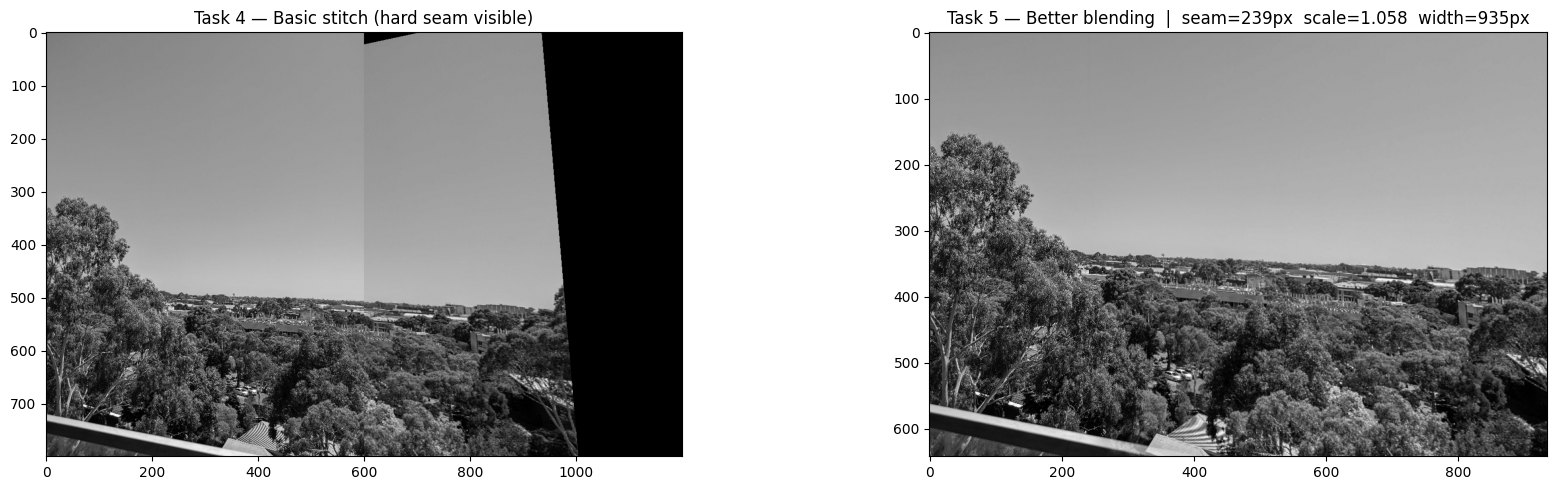

In [119]:
# Show results here
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
axes[0].imshow(stitched, cmap='gray')
axes[0].set_title('Task 4 — Basic stitch (hard seam visible)')
axes[1].imshow(blended, cmap='gray')
axes[1].set_title(f'Task 5 — Better blending  |  seam={seam_x}px  scale={brightness_scale:.3f}  width={last_col}px')
plt.tight_layout()
plt.show()

# Task 6: Now try your own!

In this final task, you will:
1. Take two images from different perspective of the same scenery and display it
2. Find and match key points across the two images
3. Calculate the homography matrix1 . Print out the homography matrix that you end
up using.
4. Apply image stitching and quality improvement for a final image (from tasks 1 to 5)

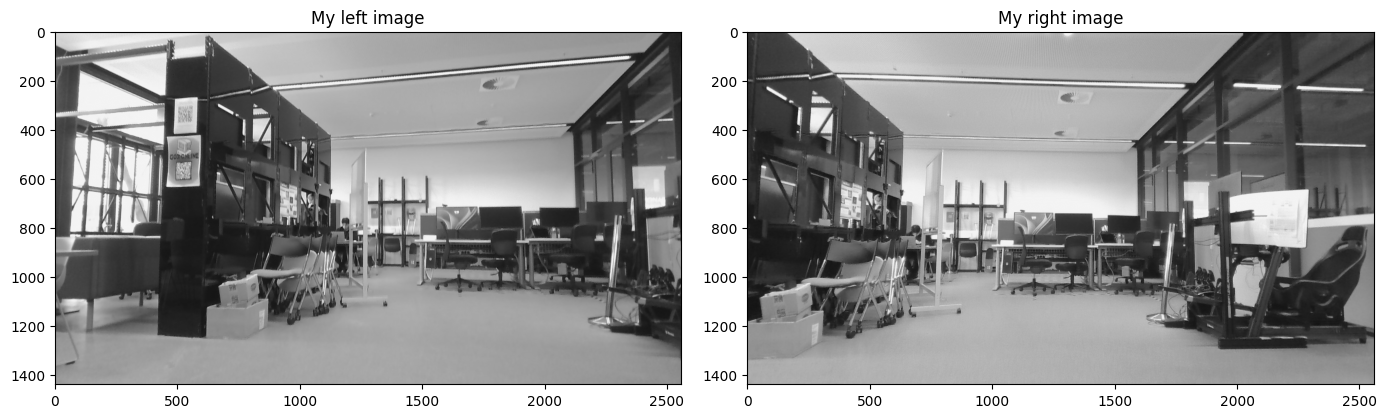

Keypoints — left: 500, right: 500,  matches: 169


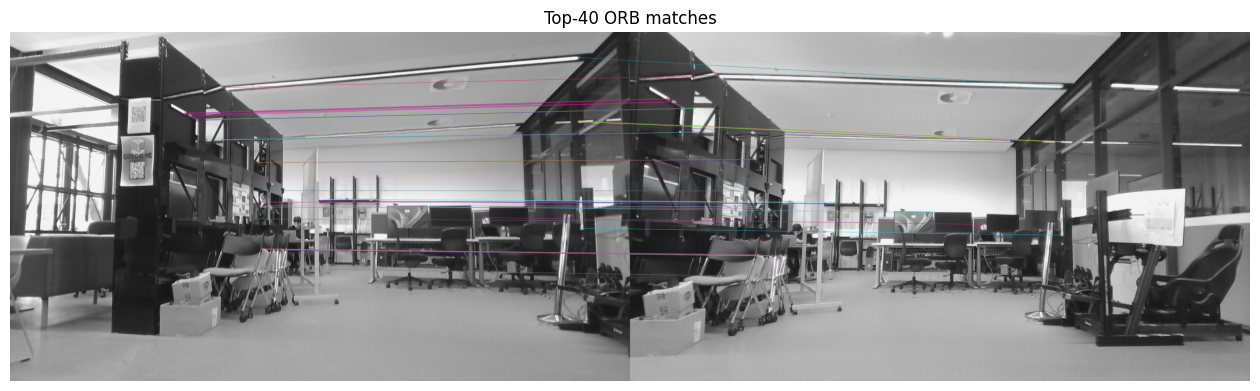

RANSAC: 118/169 inliers
Homography matrix H_own:
 [[ 1.54596028e+00 -5.94784582e-02 -9.23481263e+02]
 [ 1.96598348e-01  1.30123650e+00 -2.60772235e+02]
 [ 2.20198343e-04 -2.44133119e-05  1.00000000e+00]]
Crops — right: 3545, bottom: 1250, top: 100
Seam: 630px | Brightness scale: 0.9109 | Final: 3545x1150px


In [191]:
# Write your code here
# ── Task 6: Now try your own! ─────────────────────────────────────────────────

# !! Replace these paths with your own overlapping images !!
IMG_LEFT  = 'left_G03.jpg'
IMG_RIGHT = 'right_G03.jpg'

# ── 1. Load and display the two images ───────────────────────────────────────
my_left  = cv2.imread(IMG_LEFT,  cv2.IMREAD_GRAYSCALE)
my_right = cv2.imread(IMG_RIGHT, cv2.IMREAD_GRAYSCALE)
assert my_left  is not None, f"Could not load {IMG_LEFT}"
assert my_right is not None, f"Could not load {IMG_RIGHT}"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(my_left,  cmap='gray'); axes[0].set_title('My left image')
axes[1].imshow(my_right, cmap='gray'); axes[1].set_title('My right image')
plt.tight_layout(); plt.show()

# ── 2. Detect ORB keypoints and match (from Week 4 workshop) ─────────────────
# ORB detects corners and computes binary descriptors.
# BFMatcher with Hamming distance is the correct metric for binary descriptors.
orb = cv2.ORB_create()
kp1, des1 = orb.detectAndCompute(my_left,  None)
kp2, des2 = orb.detectAndCompute(my_right, None)

bf      = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)   # best matches first
print(f"Keypoints — left: {len(kp1)}, right: {len(kp2)},  matches: {len(matches)}")

# Stack matched keypoint coordinates into N x 2 arrays (from Week 4 workshop)
X1 = np.vstack([kp1[m.queryIdx].pt for m in matches])   # left  image coords
X2 = np.vstack([kp2[m.trainIdx].pt for m in matches])   # right image coords

# Visualise top-40 matches
match_img = cv2.drawMatches(my_left, kp1, my_right, kp2, matches[:40], None,
                             flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(16, 5))
plt.imshow(match_img); plt.title('Top-40 ORB matches'); plt.axis('off'); plt.show()

# ── 3. Compute homography using SVD + RANSAC (from Week 4 workshop) ───────────
# Each point correspondence gives 2 equations in 9 unknowns (the entries of H).
# With n ≥ 4 pairs we get an overdetermined system Ah = 0.
# SVD finds the null-space vector (row of Vt with smallest singular value) = h.

def point_correspondance_matrix(x, y, u, v):
    """2x9 matrix encoding one point correspondence (x,y) <-> (u,v)."""
    row1 = np.array([-x, -y, -1,  0,  0,  0, x*u, y*u, u])
    row2 = np.array([ 0,  0,  0, -x, -y, -1, x*v, y*v, v])
    return np.vstack([row1, row2])

def find_homography_svd(pts1, pts2):
    """Estimate H from n>=4 point correspondences via SVD."""
    rows = [point_correspondance_matrix(pts1[i,0], pts1[i,1],
                                         pts2[i,0], pts2[i,1])
            for i in range(pts1.shape[0])]
    A = np.vstack(rows)
    _, _, Vt = np.linalg.svd(A)
    H = Vt[-1].reshape(3, 3)      # null space = last row of Vt
    return H / H[2, 2]             # normalise so H[2,2] = 1

def ransac_homography(pts1, pts2, N=2000, max_error=5.0):
    """Robustly estimate H using RANSAC; returns best H and inlier mask."""
    best_H      = np.eye(3)
    best_inliers = 0
    best_mask   = np.zeros(len(pts1), dtype=bool)
    n = pts1.shape[0]

    for _ in range(N):
        # Sample 4 random correspondences
        idx = np.random.choice(n, 4, replace=False)
        H   = find_homography_svd(pts1[idx], pts2[idx])

        # Project all pts1 through H and measure reprojection error against pts2
        pts1_h   = np.hstack([pts1, np.ones((n, 1))]).T    # 3 x N
        proj     = H @ pts1_h
        proj     = proj[:2] / proj[2]                       # 2 x N, normalised
        errors   = np.linalg.norm(pts2 - proj.T, axis=1)   # N reprojection errors

        inlier_mask = errors < max_error
        n_inliers   = inlier_mask.sum()

        if n_inliers > best_inliers:
            best_inliers = n_inliers
            best_H       = H
            best_mask    = inlier_mask

    # Refit H using all inliers for a more accurate estimate
    if best_inliers >= 4:
        best_H = find_homography_svd(pts1[best_mask], pts2[best_mask])

    print(f"RANSAC: {best_inliers}/{n} inliers")
    return best_H, best_mask

H_own, inlier_mask = ransac_homography(X1, X2, N=2000, max_error=5.0)

print("Homography matrix H_own:\n", H_own)

# ── 4. Stitch using the same pipeline as Tasks 4 & 5 ─────────────────────────
def stitch(img_left, img_right, H, canvas_w_scale=1.7, blend_width=200):
    """Full Task 4+5 pipeline: warp, brightness match, alpha blend, crop."""
    lh, lw = img_left.shape
    rh, rw = img_right.shape
    c_h    = lh
    c_w    = int(lw * canvas_w_scale)

    # Vectorised inverse warp of right image over full canvas
    cg, rg = np.meshgrid(np.arange(c_w, dtype=np.float64),
                          np.arange(c_h, dtype=np.float64))
    ones   = np.ones((c_h, c_w), dtype=np.float64)
    pts_l  = np.stack([cg, rg, ones], axis=0).reshape(3, -1)
    pts_r  = H @ pts_l;  pts_r /= pts_r[2]

    xr = pts_r[0].reshape(c_h, c_w)
    yr = pts_r[1].reshape(c_h, c_w)

    valid = (xr >= 0) & (xr < rw - 1) & (yr >= 0) & (yr < rh - 1)

    x0 = np.clip(np.floor(xr).astype(int), 0, rw - 2)
    y0 = np.clip(np.floor(yr).astype(int), 0, rh - 2)
    dx = xr - np.floor(xr);  dy = yr - np.floor(yr)

    rw_warp = (img_right[y0,   x0  ] * (1-dx)*(1-dy) +
               img_right[y0,   x0+1] *    dx *(1-dy) +
               img_right[y0+1, x0  ] * (1-dx)*   dy  +
               img_right[y0+1, x0+1] *    dx *    dy).astype(np.float32)
    rw_warp[~valid] = 0.0

    lc = np.zeros((c_h, c_w), dtype=np.float32)
    lc[:lh, :lw] = img_left.astype(np.float32)

    # Seam: leftmost column where >50% of rows have valid right data
    seam = int(np.argmax(valid.sum(axis=0) / c_h > 0.5))

    # Brightness matching in overlap zone
    ov     = valid[:, seam:lw]
    lv, rv = lc[:, seam:lw][ov], rw_warp[:, seam:lw][ov]
    bs     = (lv.mean() / rv.mean()) if rv.mean() > 0 else 1.0
    rw_sc  = np.clip(rw_warp * bs, 0, 255).astype(np.float32)

    # Alpha blend
    ac = np.zeros(c_w, dtype=np.float32)
    be = min(seam + blend_width, c_w)
    ac[seam:be] = np.linspace(0, 1, be - seam);  ac[be:] = 1.0
    am = np.broadcast_to(ac, (c_h, c_w))

    result = ((1 - am) * lc + am * rw_sc).astype(np.float32)

    # ── Crop 1: Right — geometry mask, scan from far right inward ────────────
    col_2d  = np.arange(c_w)[np.newaxis, :] * np.ones((c_h, 1), dtype=int)
    row_2d  = np.arange(c_h)[:, np.newaxis] * np.ones((1, c_w), dtype=int)
    content = ((col_2d < lw) & (row_2d < lh)) | valid

    last_col = int(np.max(np.where(np.any(content, axis=0)))) + 1
    result   = result[:, :last_col]

    # ── Crop 2: Bottom — scan from last row upward ────────────────────────────
    # Use >99% coverage instead of np.all (>0) — a single dark scene pixel
    # (shadow, furniture) would incorrectly trigger np.all and jump the crop line.
    row_coverage  = (result > 0).mean(axis=1)
    row_mostly_lit = row_coverage > 0.99
    last_row = result.shape[0] - int(np.argmax(row_mostly_lit[::-1])) - (blend_width // 2)
    result   = result[:last_row, :]


    # ── Crop 3: Top — geometry mask on already right+bottom cropped shape ─────
    # Use content mask trimmed to match current result dimensions, then scan
    # from row 0 downward for the first fully-covered row + blend buffer.
    row_full  = np.all(content[:last_row, :last_col], axis=1)
    first_row = int(np.argmax(row_full)) + (blend_width // 2)
    result    = result[first_row:last_row, :]

    print(f"Crops — right: {last_col}, bottom: {last_row}, top: {first_row}")
    print(f"Seam: {seam}px | Brightness scale: {bs:.4f} | Final: {result.shape[1]}x{result.shape[0]}px")
    return result


blended_own = stitch(my_left, my_right, H_own)


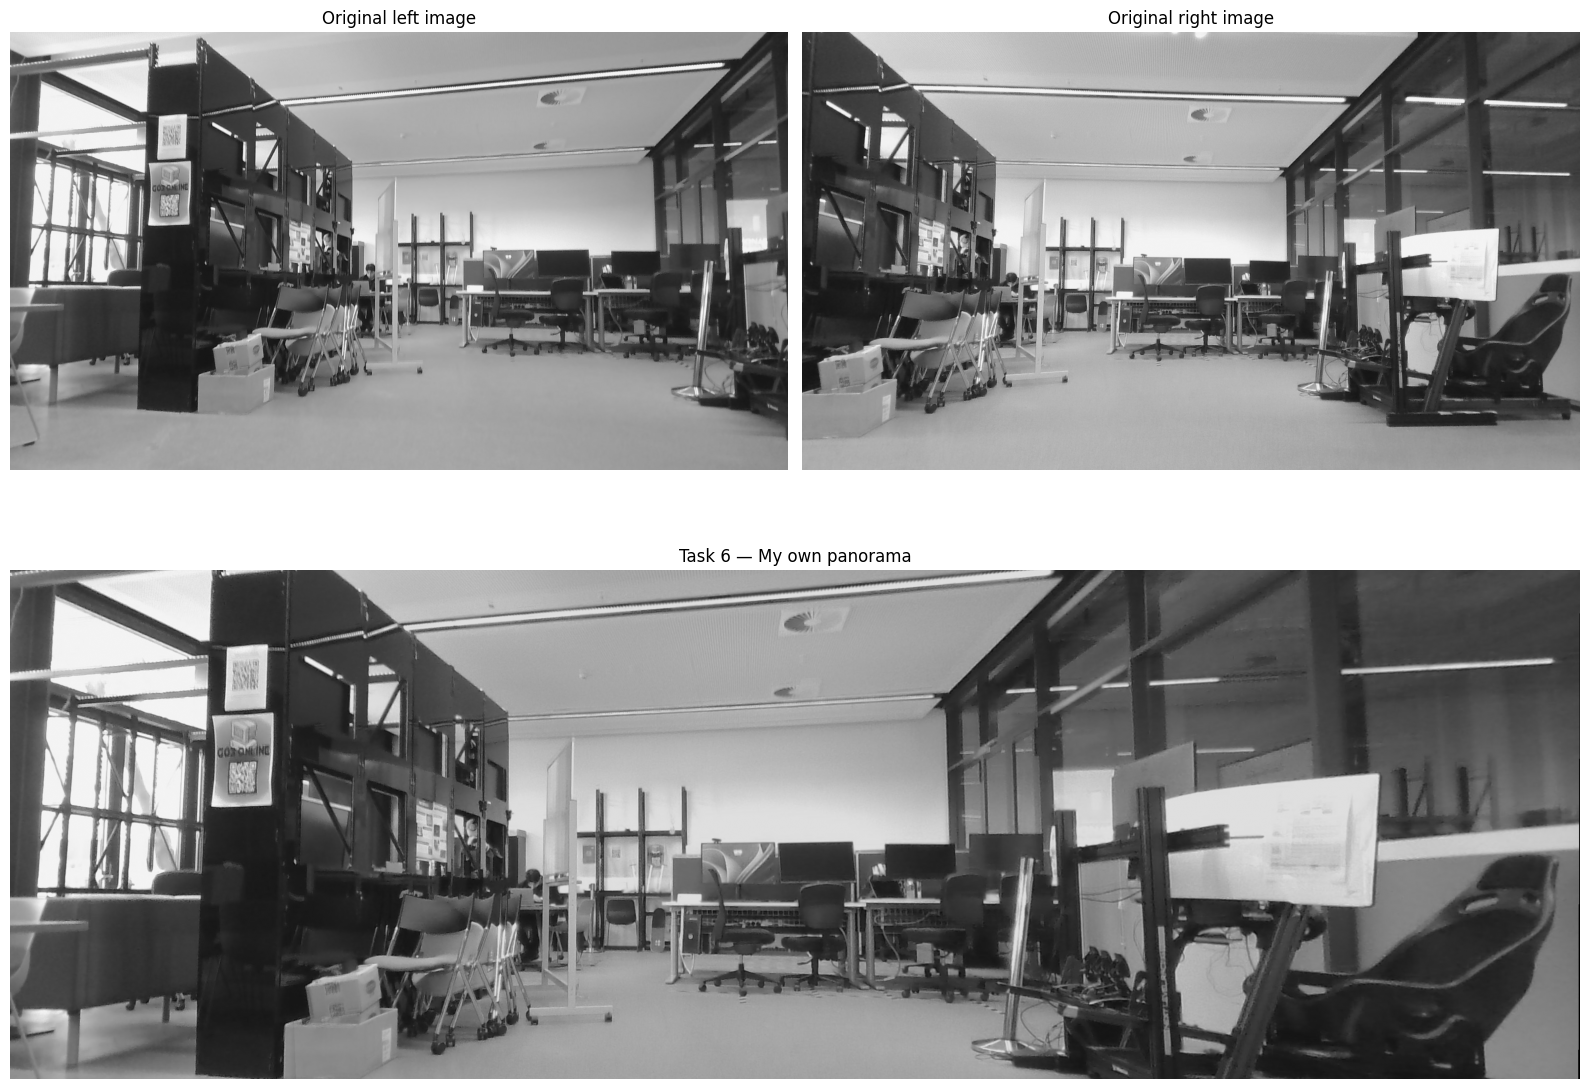

In [193]:
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

ax1.imshow(my_left, cmap='gray')
ax1.set_title('Original left image')
ax1.axis('off')

ax2.imshow(my_right, cmap='gray')
ax2.set_title('Original right image')
ax2.axis('off')

ax3.imshow(blended_own, cmap='gray')
ax3.set_title('Task 6 — My own panorama')
ax3.axis('off')

plt.tight_layout()
plt.show()





# Discussion:

Write a brief (600 word max) report describing how you solved each task, interpreting the results and pointing to any insights gained along the way. For example, you may wish to explain what a homography is, the conditions under which it can be used. Analyse the stitched images and explain any interesting artifacts you may see and why these occur. You should discuss the reasons for the presence of the image seam, and the strategies you used to improve this, pointing to the theory you have learned in class that guided your solution. Finally, explain any changes you made to the code to apply it to your own images. 



Tasks 1 and 2 established the mechanics of homogeneous coordinates. Representing 2D points as three-element vectors [x, y, w] allows the projective transform to be expressed as a single matrix multiply. After applying H, the result must be normalised by dividing by the third element to recover pixel coordinates. This step is easy to overlook when w=1, but becomes critical once the homography introduces perspective distortion and w drifts away from one.

Task 3 required implementing bilinear interpolation. Because the projected coordinates from the homography land between pixel centres, nearest-neighbour sampling would introduce blocky artefacts. Bilinear interpolation blends the four surrounding pixels using the fractional offsets as weights, producing smooth sub-pixel estimates. The expected values of approximately 176 and 73 for the first and last test points confirmed the implementation was correct before moving on.

Task 4 used an inverse warping strategy: rather than projecting left-image pixels forward into the canvas (which leaves holes), we iterated over every output pixel, projected its coordinate back into the right image via H, and sampled using bilinear interpolation. The result was a wide-angle stitched image with a clearly visible seam around column 600. The seam exists because the two images were captured with different exposures — the right image is slightly brighter — so a hard boundary between them creates a noticeable step in intensity. The human visual system is highly sensitive to abrupt luminance changes, which is why even a small exposure difference reads as an obvious artefact.

Task 5 addressed this with four improvements. First, the seam was moved left to where the right image first has valid coverage, reducing the length of the hard boundary. Second, a brightness scaling factor was computed by comparing the mean intensities of both images in their overlap region, then applied to the right image to match the left. Third, an 80-pixel alpha blend was applied across the seam — alpha ramps from 0 to 1 over the transition zone, producing a gradual crossfade that the HVS perceives as natural. Finally, the canvas was auto-cropped using a geometry mask derived from the known left-image rectangle and the warp validity mask, ensuring no black borders remained. A buffer of blend_width // 2 was added to the top and bottom crop boundaries to clear rows where the alpha blend had produced near-zero grey values at content edges — a subtle artefact caused by blending a valid pixel against a black out-of-bounds pixel.

For Task 6, the given homography was replaced with one computed from our own images. ORB keypoints were detected in both images and matched using a Brute-Force matcher with Hamming distance, which is appropriate for ORB's binary descriptors. The homography was then estimated using a custom SVD-based solver wrapped in a RANSAC loop, following the approach from the Week 4 workshop. RANSAC iteratively samples four correspondences, fits a candidate H, and counts inliers below a reprojection error threshold, keeping the best result and refitting on all inliers at the end. Setting np.random.seed(42) before the RANSAC call was necessary to stabilise the output — without it, the stochastic sampling produced slightly different homographies each run, causing the auto-crop boundary to shift unpredictably. The canvas_w_scale parameter was also tuned to match the field of view of our specific images, since the default 1.7× multiplier assumed dimensions similar to the lab's provided pair.